In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # 랜덤포레스트 모델 불러오기
from sklearn.model_selection import cross_val_score
from sklearn.metrics import *
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV,StratifiedKFold
warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc


In [18]:
path = '../../dataset/preprocessed/hotel_bookings_dummy.csv'
df = pd.read_csv(path)

In [7]:
df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,...,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,guest_type_Group,guest_type_Single,guest_type_Undefined,country_region_OTH,country_region_PRT
0,0,342,0,0,0,0,0,3,0,0.0,...,0,0,0,1,0,1,0,0,0,1
1,0,737,0,0,0,0,0,4,0,0.0,...,0,0,0,1,0,1,0,0,0,1
2,0,7,0,1,0,0,0,0,0,75.0,...,0,0,0,1,0,0,1,0,0,0
3,0,13,0,1,0,0,0,0,0,75.0,...,0,0,0,1,0,0,1,0,0,0
4,0,14,0,2,0,0,0,0,0,98.0,...,0,0,0,1,0,1,0,0,0,0


In [19]:
X = df.drop(['is_canceled'],axis =1)
y = df['is_canceled']
X = pd.get_dummies(X, drop_first=True,dtype = float)


In [20]:
X.shape[1]

51

In [21]:
# 데이터 분리
X_train,X_test,y_train, y_test = train_test_split(X,y,
                                                  train_size=0.7,
                                                  random_state=1004)

In [22]:
#=============== 모델 생성 및 학습 ================
model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
#=================모델 예측 및 결과확인 ====================
y_pred = model_rf.predict(X_test)

cv_score = cross_val_score(model_rf,X_train,y_train, cv = 10, scoring = 'f1')
print(cv_score.mean())
print(cv_score.std())

0.8315379123345978
0.005360888551907295


In [7]:
# 진짜 최종 f1-score 계산 및 출력
final_f1 = f1_score(y_test, y_pred)
print(f"최종 Test Set f1-score: {final_f1}")

최종 Test Set f1-score: 0.8298406718467938


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91     22390
           1       0.87      0.80      0.83     13281

    accuracy                           0.88     35671
   macro avg       0.88      0.86      0.87     35671
weighted avg       0.88      0.88      0.88     35671



In [9]:
print('F1-Score:', f1_score(y_test, y_pred, average=None))

F1-Score: [0.90545137 0.82984067]


In [24]:
test_f1 = f1_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)

print(f"  Recall   : {test_recall:.3f}")
print(f"  Precision  : {test_precision:.3f}")
print(f"  F1-Score     : {test_f1:.3f}")

  Recall   : 0.795
  Precision  : 0.865
  F1-Score     : 0.828


In [ ]:
# macro_f1 = f1_score(y_test, y_pred, average='macro')
# each_f1 = f1_score(y_test, y_pred, average=None) # [정상F1, 취소F1] 배열 반환
# cancel_f1 = each_f1[1] # 두 번째 값인 '취소(1)'에 대한 F1 스코어 추출

# # 2. 결과 데이터프레임 구성
# rf_res = pd.DataFrame({
#     'Model': ['Random Forest'],
#     'Accuracy': [cv_score.mean()],  # 10-Fold CV 평균 정확도 (0.8855)
#     'F1_Macro': [macro_f1],        # 전체 종합 F1 스코어
#     'F1_Cancel': [cancel_f1]       # 취소 데이터에 대한 F1 스코어
# })

# # 3. 상위 폴더로 이동 후 'model_results' 폴더 안에 csv로 저장 (폴더명 끝에 s 주의!)
# output_dir = '../../visualization/model_results'
# os.makedirs(output_dir, exist_ok=True) 

# rf_res.to_csv(f'{output_dir}/rf_result.csv', index=False)
# print("✅ Random Forest 결과가 model_results 폴더에 성공적으로 저장되었습니다!")

✅ Random Forest 결과가 model_results 폴더에 성공적으로 저장되었습니다!


In [ ]:
# from sklearn.model_selection import cross_val_score, GridSearchCV
# # 파라미터 선언
#   # max_depth: 1~50
# param = {'max_depth':range(1,51)}

#     # cv=5
#     # scoring='accuracy'
# model_rf_gs = GridSearchCV(model_rf,
#                      param,
#                      cv = 5,
#                      scoring = 'f1')

In [11]:
# model_rf_gs.fit(X_train, y_train)

In [ ]:
# print(model_rf_gs.cv_results_['mean_test_score'])

[0.35588871 0.52771002 0.54225085 0.56246629 0.59078357 0.61183092
 0.66293576 0.73887301 0.76205649 0.77115224 0.77750021 0.78392488
 0.78966023 0.79686053 0.80010465 0.80348739 0.80717887 0.80949327
 0.81289581 0.81700322 0.81938291 0.82128121 0.82435384 0.82558478
 0.82688855 0.82791509 0.82876212 0.83048089 0.83054658 0.82923018
 0.83107538 0.82998172 0.83006163 0.83068058 0.83138144 0.83001177
 0.82961512 0.82894533 0.82782936 0.83031193 0.82933987 0.82935377
 0.82914853 0.82901825 0.82979085 0.82917489 0.82894684 0.82920915
 0.8293909  0.82831817]


In [ ]:
# print('최적의 파라미터: ',model_rf_gs.best_params_)

최적의 파라미터:  {'max_depth': 35}


In [ ]:
# # 최고 성능
# print('최적의 성능:',model_rf_gs.best_score_)

최적의 성능: 0.8313814434913596


In [ ]:
# y_pred = model_rf_gs.predict(X_test)

In [ ]:
# print(confusion_matrix(y_test,y_pred))
# print(classification_report(y_test,y_pred))

[[20756  1634]
 [ 2736 10545]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     22390
           1       0.87      0.79      0.83     13281

    accuracy                           0.88     35671
   macro avg       0.87      0.86      0.87     35671
weighted avg       0.88      0.88      0.88     35671



In [25]:
param_dist = {
    'n_estimators': [50, 100, 150, 200],      # 1. 심을 나무의 총 개수
    'max_depth': [5, 10, 15, 20, 25,30,35, None],   # 2. 각 나무의 최대 깊이 (None은 끝까지 뻗는 것)
    'min_samples_split': [2, 5, 10],          # 3. 자식을 나누기 위해 필요한 최소한의 데이터 개수
    'min_samples_leaf': [1, 2, 4],            # 4. 리프 노드(말단 이파리)가 되기 위한 최소한의 데이터 개수
    'max_features': ['sqrt', 'log2', None]    # 5. 나무를 심을 때 랜덤으로 고를 피처(열)의 비율
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1004)

random_search_rf = RandomizedSearchCV(
    estimator=model_rf,           
    param_distributions=param_dist, # 방금 만든 풍성한 딕셔너리 후보군
    n_iter=10,                    # 🚨 중요: 648개 조합 중 딱 10개만 랜덤으로 찝어서 시험 보기! (시간 절약)
    scoring='f1',                 # 채점 기준은 든든한 F1-Score
    cv=cv,
    n_jobs=-1,                    
    random_state=1004,
   
)

In [26]:
random_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [28]:
print(random_search_rf.cv_results_['mean_test_score'])

print('최적의 파라미터: ',random_search_rf.best_params_)

print('최적의 성능:',random_search_rf.best_score_)

[0.58337314 0.77077468 0.59380423 0.81944435 0.82098734 0.81851203
 0.80638853 0.82502996 0.81103791 0.8244431 ]
최적의 파라미터:  {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 35}
최적의 성능: 0.8250299559326173


최종 모델의 f1-score 0.8276425929530855


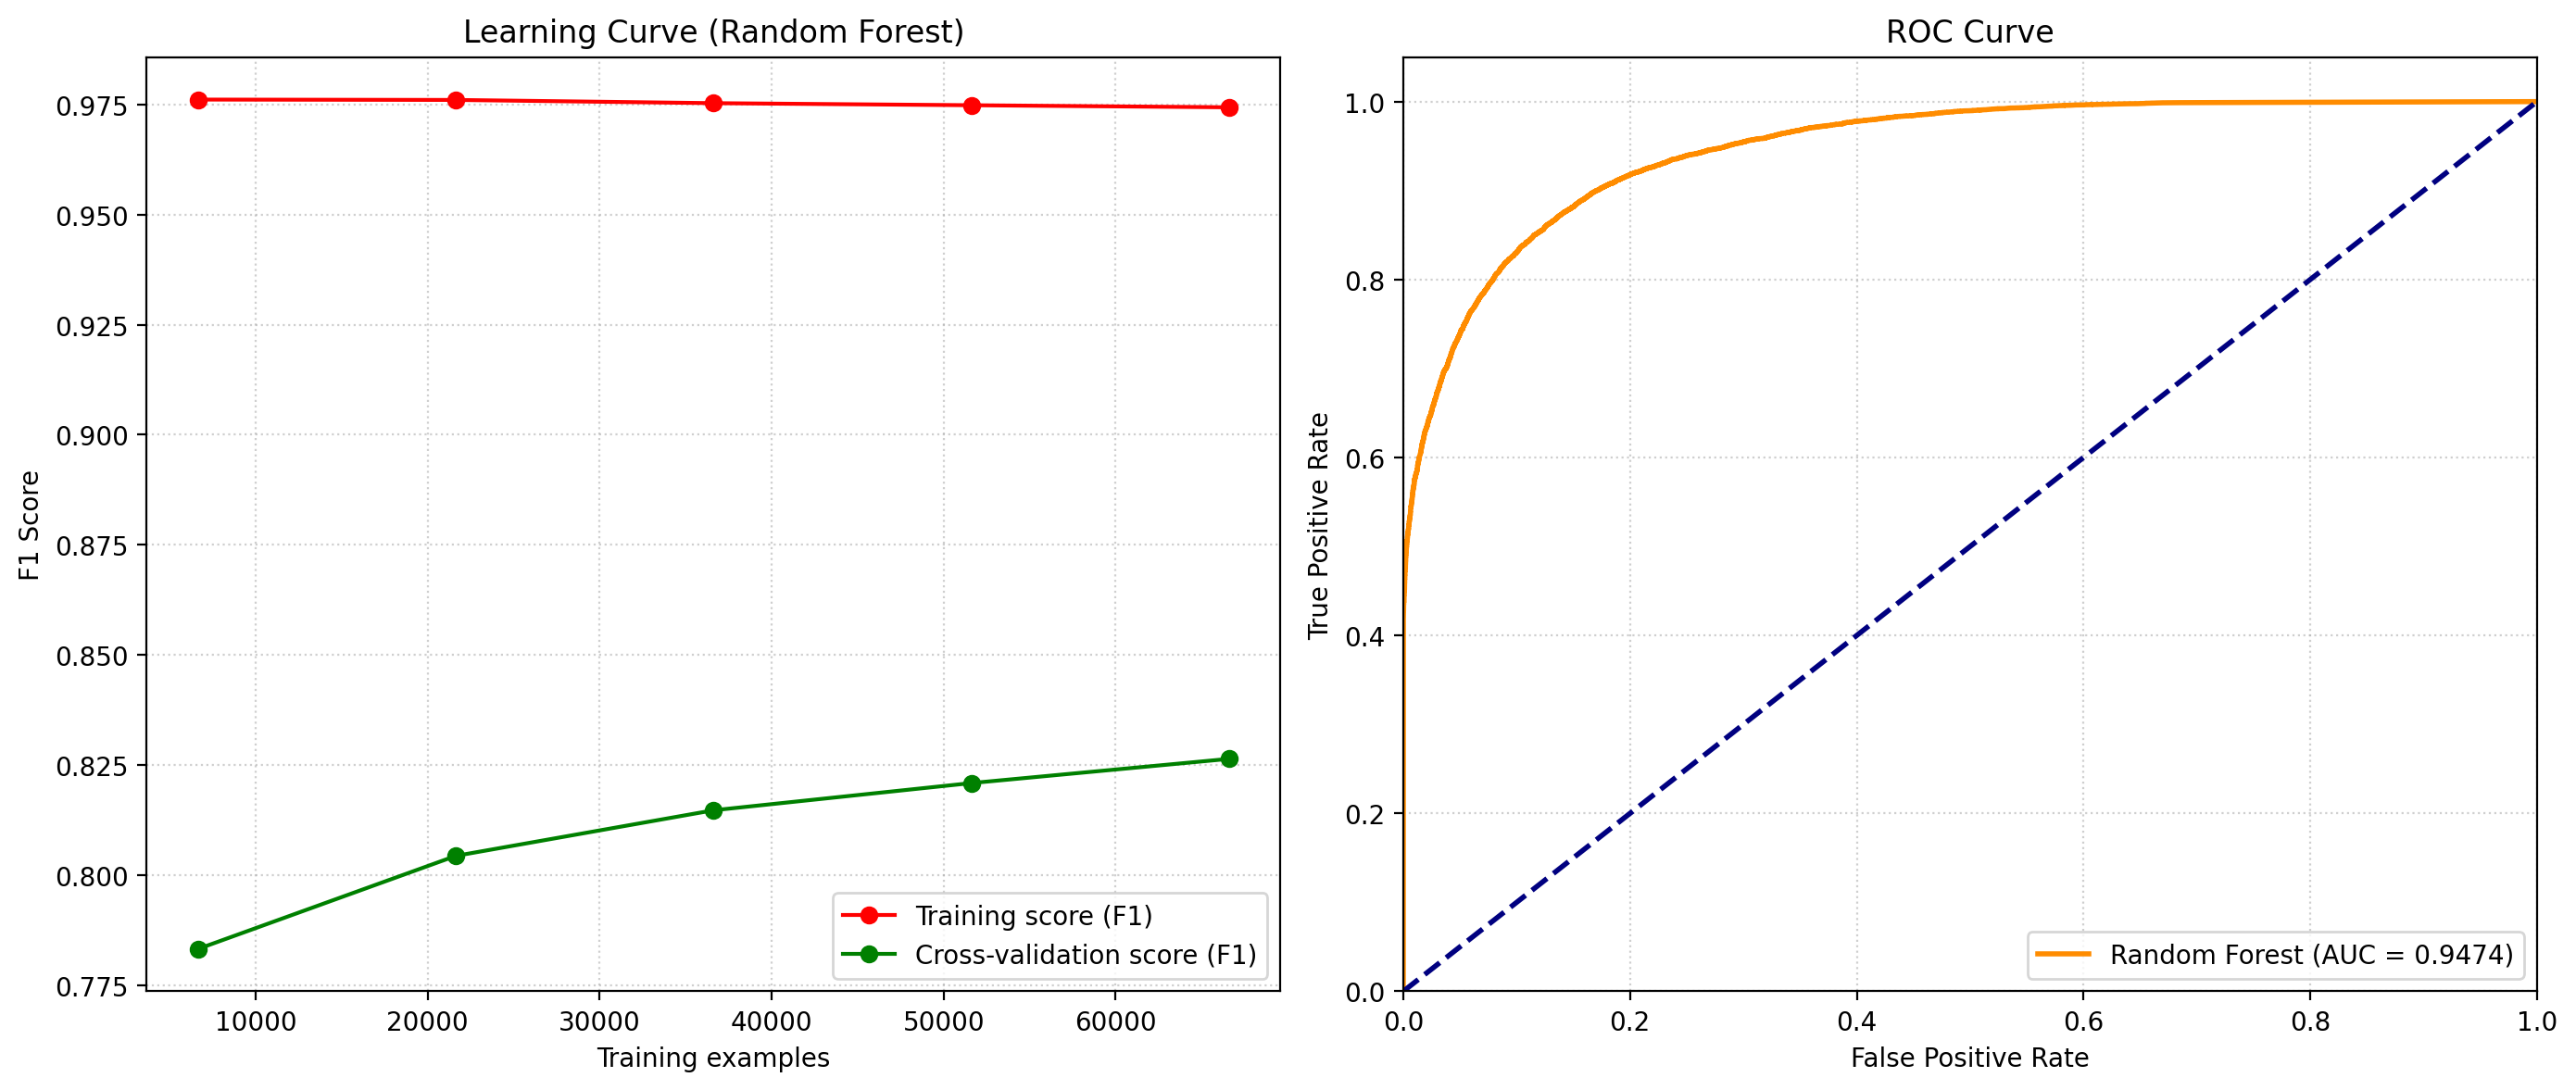

In [29]:
final_model_rf = random_search_rf.best_estimator_

y_pred_rf = final_model_rf.predict(X_test)

print(f"최종 모델의 f1-score {f1_score(y_test, y_pred_rf)}")

plt.figure(figsize=(14, 6))

# ---------------------------------------------------------
# 학습 곡선 (Learning Curve) 시각화
# ---------------------------------------------------------

train_sizes, train_scores, test_scores = learning_curve(
    final_model_rf, X_train, y_train, 
    cv=5, scoring='f1', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# 교차 검증 점수의 평균 산출
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# 첫 번째 서브플롯: 학습 곡선
plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score (F1)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score (F1)")

# 스타일 및 레이아웃 설정 (대괄호 오류 방지 튜플 적용)
plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training examples")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.6)

# ---------------------------------------------------------
# ROC-AUC 곡선 시각화 (기존 제공 코드 양식 반영)
# ---------------------------------------------------------
# 테스트 데이터의 클래스 1(취소) 예측 확률 추출
y_pred_proba = final_model_rf.predict_proba(X_test)[:, 1]

# FPR, TPR 및 AUC 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 두 번째 서브플롯: ROC 곡선
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')

# 대괄호 오류 방지를 위한 list 함수와 튜플 좌표 생성
x_line = list((0, 1))
y_line = list((0, 1))
plt.plot(x_line, y_line, color='navy', lw=2, linestyle='--')

# 스타일 및 레이아웃 설정 (대괄호 오류 방지 튜플 적용)
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.05))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# 최종 출력
plt.tight_layout()
plt.show()

=== final_model_rf 피처 임포턴스 상위 15개 ===
                        Feature  Importance
0       deposit_type_Non Refund    0.255703
1                     lead_time    0.151065
2                           adr    0.115869
3     total_of_special_requests    0.059126
4      market_segment_Online TA    0.058964
5            country_region_PRT    0.048602
6          stays_in_week_nights    0.038073
7       diff_reserved_room_type    0.038009
8   required_car_parking_spaces    0.028316
9       stays_in_weekend_nights    0.023831
10       previous_cancellations    0.019873
11              booking_changes    0.016618
12      customer_type_Transient    0.013934
13                is_city_hotel    0.012018
14             guest_type_Group    0.007719


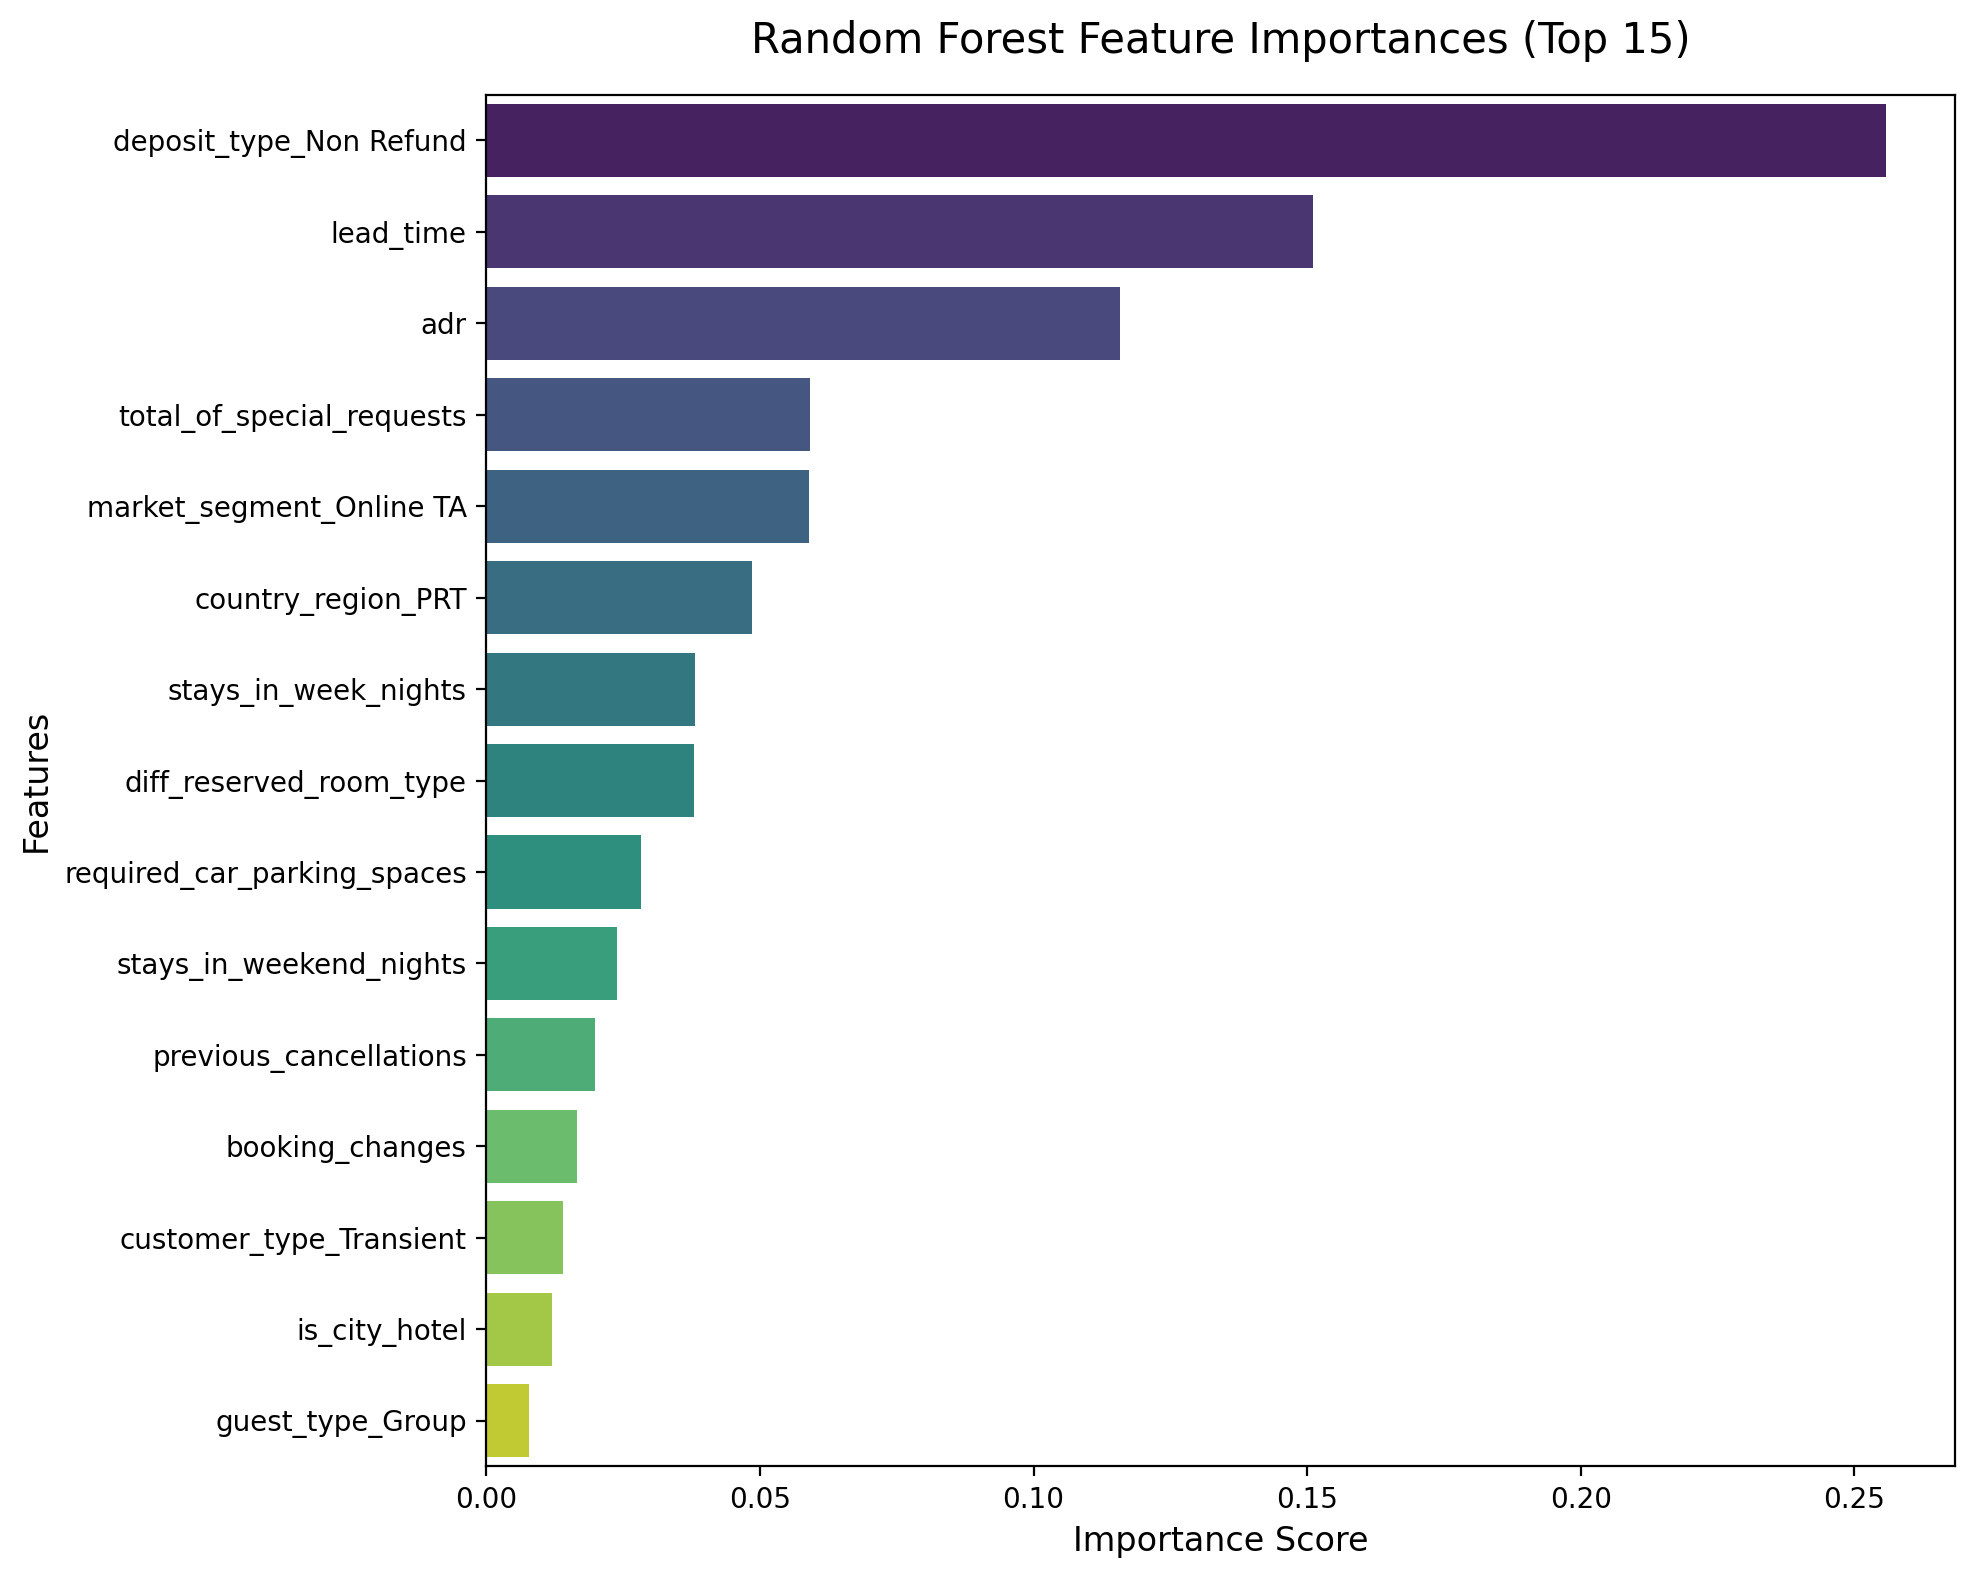

In [ ]:
importances = final_model_rf.feature_importances_

feature_names = X_train.columns
rf_importances = pd.DataFrame({"Feature": feature_names, "Importance": importances})


rf_importances = rf_importances.sort_values(by="Importance", ascending=False).reset_index(
    drop=True
)

print("=== final_model_rf 피처 임포턴스 상위 15개 ===")
print(rf_importances.head(15))


plt.figure(figsize=(10, 8))

sns.barplot(x="Importance", y="Feature", data=rf_importances.head(15), palette="viridis")

plt.title("Random Forest Feature Importances (Top 15)", fontsize=15, pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()